In [28]:
%load_ext autoreload
%autoreload 3

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Часть 1 - Методы uplift-моделирования

## Этап 1 - Первичная подготовка данных
- выполнить шаги
    - импортируйте необходимые библиотеки для работы с данными и визуализацией;
    - загрузите датасет;
    - заполните пропуски в датасете, если они есть.

In [92]:
import pandas as pd

data = pd.read_csv('data/initial/uplift_fp_data.csv')
display(data)
data.info()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
0,10,1,142.44,1,0,1,0,1,1,0
1,6,2,329.08,1,1,2,1,2,0,0
2,7,1,180.65,0,1,1,1,2,1,0
3,9,4,675.83,1,0,2,1,2,0,0
4,2,0,45.34,1,0,0,0,2,1,0
...,...,...,...,...,...,...,...,...,...,...
63995,10,1,105.54,1,0,0,0,2,0,0
63996,5,0,38.91,0,1,0,1,1,0,0
63997,6,0,29.99,1,0,0,1,1,0,0
63998,1,4,552.94,1,0,1,1,0,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  int64  
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  int64  
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  int64  
 8   treatment        64000 non-null  int64  
 9   target           64000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 4.9 MB


Результат 
- данные загружены
- всего 64000 строки
- пропусков нет (все признаки содержат полный набор 64000 not-null записей)

## Этап 2 - EDA - Проведение исследовательского анализа данных

#### Проверка сбалансированности выборки
- оценим распределение целевой переменной между контрольной и тестовой группами

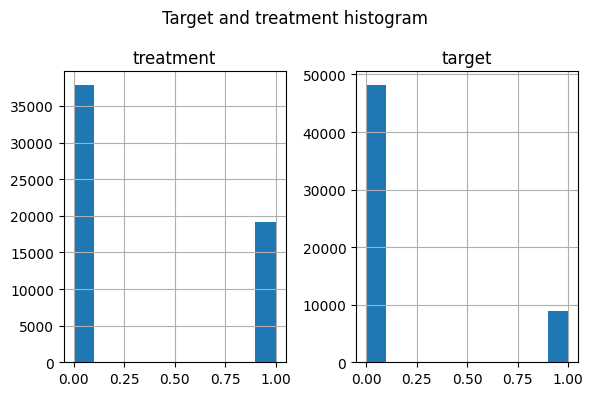

In [192]:
import matplotlib.pyplot as plt 

features_all = ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']
treatment = ['treatment']
target = ['target']

# общий обзор гистограммы
data[treatment + target].hist(figsize=(6,4))
plt.suptitle('Target and treatment histogram')
plt.tight_layout()

In [193]:
pd.crosstab(data.target, data.treatment)

treatment,0,1
target,,
0,32051,16090
1,5775,3069


In [101]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

def calc_group_data(data: pd.DataFrame, plot: bool = True):
    group_data = data.groupby(by=['treatment']).agg(
        group_count=('target', 'count'),
        target_action=('target', 'sum'),
        conversion=('target', lambda x: round(x.mean(), 6)),
        conversion_std=('target', lambda x: round(x.std(), 6)),
        conversion_var=('target', lambda x: round(x.var(), 6))) \
        .reset_index()
    display(group_data)

    convA = group_data.query('treatment == 0')['conversion'].iat[0]
    convB = group_data.query('treatment == 1')['conversion'].iat[0]

    uplift = convB-convA

    print(f'Прирост конверсии в тестовой группе = {100*(uplift):.2f}%')
    print(f'Относительное увеличение конверсии = {100*(uplift/convA):.2f}%')

    if plot:
        fig,axs = plt.subplots(1,2, figsize=(10,5))

        sns.barplot(data=group_data, x='treatment', y='group_count', label='group count', width=0.5, ax=axs[0])
        sns.barplot(data=group_data, x='treatment', y='target_action', label='target action', width=0.5, ax=axs[0])
        sns.barplot(data=group_data, x='treatment', y='conversion', label='conversion', width=0.5, ax=axs[1])

        axs[0].grid()
        axs[1].grid()
        axs[1].set_ylim((0, 0.18))
        fig.suptitle('Распределение целевой переменной по группам')
        fig.tight_layout()

    return uplift, convA, convB, group_data

,treatment,group_count,target_action,conversion,conversion_std,conversion_var
0,0,42613,6156,0.144463,0.351563,0.123596
1,1,21387,3238,0.151400,0.358447,0.128484


Прирост конверсии в тестовой группе = 0.69%
Относительное увеличение конверсии = 4.80%


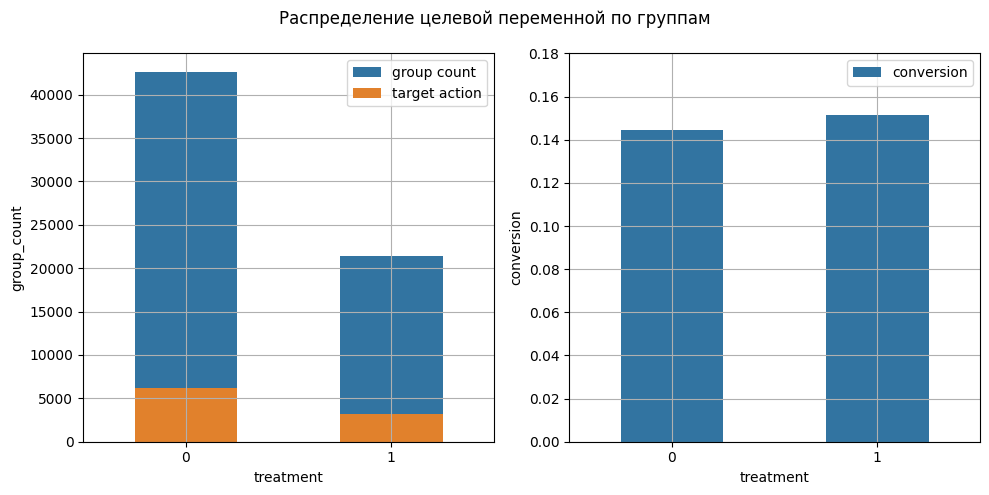

In [13]:
uplift, convA, convB, group_data = calc_group_data(data)

##### Результат
- имеем несбалансированные группы - контрольная группа (без воздействия) содержит в 2 раза больше записей в чем в тестовой (с воздействием)
    - надо будет учесть при выборе подхода uplift-моделирования, такой способ, который это учитывает (X- или R-learner)
- конверсия
    - в контрольной группе = 14,4%
    - в тестовой группе = 15,1%
    - прирост конверсии в тестовой группе = 0.69%
    - относительное увеличение конверсии = 4.78%

#### Проверка на статистическую значимость
Проверка должна показать, что в пределах допустимой ошибки 5% (стандартное отраслевое значение), полученное увеличение конверсии неслучайно (или наоборот)

Анализ способа проверки:

- целевая переменная является дискретной бинарной величиной (воспользовалася ли пользователь промокодом на доставку или нет)
- полученное распределение в двух группах - это распределение Бернулли
    - у этого распределенрия всего два возможных значений - 0 и 1 (два "горба")
    - характеристика такого распределения - это вероятность "p" реализации значения 1
        - среднее значение = p
        - дисперсия = p(1-p)
- для такой выборки "t-test" или другие тесты (Манна-Уитни) для определения "нормального распределения" не подходят
- поэтому необходимо использовать "z-тест для двух выборок" или критерий "хи-квадрат Пирсона"
- так как данных достаточно много, z-тест согласно ЦПТ должен дать удовлетворительный способ проверки

Условие применение z-теста для соответсвия ЦПТ о выборочных средних:

- объекты в выборке независимы (независимые испытания Бернулли) 
    - можем считать, что пользователи и их поведение в Яндекс Еда независимы друг от другах
    - данные не должны содержить дублирущихся пользователей или множества действия одного пользователя - так как это будут уже не независимые испытания
- выборки должны формироваться случайно
    - наличие корреляций в группах между признаками и treatment не выявлено 
- выборки должны содержать достаточное количество данных
    - условие Лапласа - выборка должна содержать минимум n*p >= 10 значений 
    - условие выполняется, так как данных существенно больше (тысячи) 

##### Проверка дубликатов 
- Проверим, нет ли дублированных записей (идентификторов пользователей не предоставлено) - поэтому только по значению

In [2]:
dup_count = len(data[data.duplicated(keep=False)])
print(f'duplicates count: {dup_count} ({100*dup_count/len(data):.2f}%)')

duplicates count: 7868 (12.29%)


Результат - есть дубликаты - 7868 записей (12.29%) 
- их необходимо удалить - иначе выборка не будет удовлетворять требования ЦПТ о независимости наблюдений 

##### Очистка от дублей

In [206]:
data_cleaned = data.drop_duplicates(ignore_index=True)
print(f'Cleaned data size: {len(data_cleaned)}')

# сохранение в файл очищенного датасета
data_cleaned.to_csv('data/uplift_fp_data_cleaned.csv', index=False)

Cleaned data size: 56985


Посмотрим на очищенные данные и обновленное распределение по группам

,treatment,group_count,target_action,conversion,conversion_std,conversion_var
0,0,37826,5775,0.152673,0.359677,0.129367
1,1,19159,3069,0.160186,0.366788,0.134533


Прирост конверсии в тестовой группе = 0.75%
Относительное увеличение конверсии = 4.92%


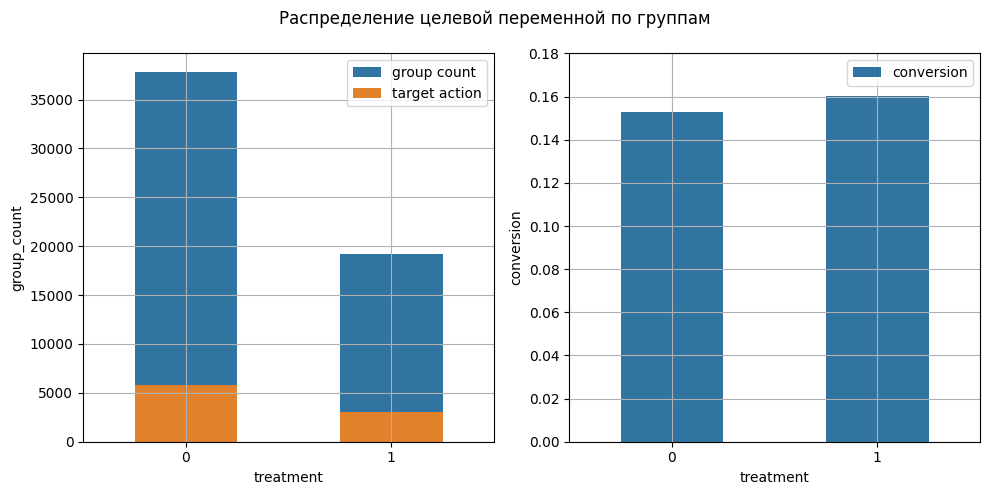

In [102]:
uplift, convA, convB, group_data_cleaned = calc_group_data(data_cleaned)

group_data_cleaned.to_csv('EDA/group_data.csv')

# сохраним в файл
plt.savefig('EDA/targret_by_groups.png', bbox_inches='tight')


##### Результат очистки
- после очистки от дублей (7868 шт / 12.29%) значение конверсии немного выросло
    - Прирост конверсии в тестовой группе = 0.75%
    - Относительное увеличение конверсии = 4.92%

##### Реализация z-теста (z-оценки)

- имеем значения конверсии по группам на основе A/B-теста - будем считать их средними значениями выборки согласно ЦПТ
    - pA, pB - где "p" среднее значение выборки (веротность того, что target = 1)
- определяем разницу двух распределений (B-A) 
    - их среднее delta = разница средних (pB-pA) 
        - их если их среднее в точке 0 - значит выборки не отличаются друг от друга - то есть обе выборки случайны 
            - нулевая гипотеза справедлива
        - если их среднее правее точки 0, значит конверсия в тестовой группе больше чем в контрольной 
            - альтернативная гипотеза справедлива
    - их стандартное отклонение (стандартная ошибка) std_err = сумме стандартных отклонений каждой выборки
- для оценки статистической значимости получения именно такой разницы расчитыаваем z-оценку
    - z-score - это расчет разницы delta (pB-pA) в единицах величины стандартного отклонения
    - z_score = delta / std_err
- определеяем `p-value` - вероятноcть того, что z-оценка отклониться от нуля именно на столько единиц стандартных отклонений при условии, что нулевая гипотеза верна
    - чем сильнее z-оценка отклоняется от нуля, тем более вероятно, что нулевая гипотеза не верна 
    - если p_value больше ожидаемой ошибки 1-ого рода (alpha = 5%), то есть основания отклонить нулевую гипотезу
    - иначе оснований считать, что результаты неслучайны, нет - A/B-тест неуспешный
    - p_value = 2*(1 - CDF(z-score)) - при этом умножаем значение на 2, чтобы учесть вероятность как улучшения базового поведения, так и ухушдения
        

Функция оценки z-score и расчета p-value

In [17]:
import scipy.stats as stat
import numpy as np

def calc_z_score(groupA, groupB):
    # данные группы A
    nA = groupA['group_count'].iat[0]
    pA = groupA['conversion'].iat[0]
    actionsA = groupA['target_action'].iat[0]
    stdA = groupA['conversion_std'].iat[0]
    varA = groupA['conversion_var'].iat[0]

    # данные группы B
    nB = groupB['group_count'].iat[0]
    pB = groupB['conversion'].iat[0]
    actionsB = groupB['target_action'].iat[0]
    stdB = groupB['conversion_std'].iat[0]
    varB = groupB['conversion_var'].iat[0]

    print(f'nA = {nA}, actionsA = {actionsA}, pA = {pA}, stdA = {stdA}, varA = {varA}')
    print(f'nB = {nB}, actionsB = {actionsB}, pB = {pB}, stdB = {stdB}, varB = {varB}')

    # расчет z-score (z-критерий Уэлча для долей)
    std_err = np.sqrt(varA/nA + varB/nB) # стандартная ошибка
    delta = (pB - pA)
    z_score = delta/std_err

    print(f'uplift (pB-pA) = {100*delta:.2f}%, std_err = {std_err:.4f}, z_score = {z_score:.4f}')

    # умножаем значение на 2, чтобы учесть вероятность как улучшения базового поведения, так и ухушдения
    p_value = 2*(1 - stat.norm.cdf(z_score))
    print(f'p_value = {100*p_value:.2f}%')

    # границы 95% доверительного интервала
    alpha = 0.05
    z_crit = stat.norm.ppf(1 - alpha / 2)
    conf_error = z_crit * std_err
    left_bound = delta - conf_error
    right_bound = delta + conf_error
    print(f'95% доверительный интервал для uplit конверсий (pB-pA) = [{100*left_bound:+.2f}%, {100*right_bound:+.2f}%] (допустимое отклонение = {100*conf_error:.2f}%)') 

    return p_value, z_score, (left_bound, right_bound) 

Расчет для исходного датасета (чисто для интереса)

In [18]:
groupA = group_data.query('treatment == 0')
groupB = group_data.query('treatment == 1')

p_value, z_score, (left_bound, right_bound) = calc_z_score(groupA, groupB)

nA = 42613, actionsA = 6156, pA = 0.144463, stdA = 0.351563, varA = 0.123596
nB = 21387, actionsB = 3238, pB = 0.1514, stdB = 0.358447, varB = 0.128484
uplift (pB-pA) = 0.69%, std_err = 0.0030, z_score = 2.3242
p_value = 2.01%
95% доверительный интервал для uplit конверсий (pB-pA) = [+0.11%, +1.28%] (допустимое отклонение = 0.58%)


Расчет для очищенного датасета (рабочий вариант)

In [19]:
groupA = group_data_cleaned.query('treatment == 0')
groupB = group_data_cleaned.query('treatment == 1')

p_value, z_score, (left_bound, right_bound) = calc_z_score(groupA, groupB)

nA = 37826, actionsA = 5775, pA = 0.152673, stdA = 0.359677, varA = 0.129367
nB = 19159, actionsB = 3069, pB = 0.160186, stdB = 0.366788, varB = 0.134533
uplift (pB-pA) = 0.75%, std_err = 0.0032, z_score = 2.3250
p_value = 2.01%
95% доверительный интервал для uplit конверсий (pB-pA) = [+0.12%, +1.38%] (допустимое отклонение = 0.63%)


##### Результат z-оценки
- получена оценка `p-value` = 2.01% ниже допустимой alpha-ошибки 5%
- разница конверсий (полученный uplift) = 0.75% входит в 95% доверительный интервал = [0.12%, 1.38%]
    - и интервал не содержит значения = 0 (что означало бы возможность ухудшения конверсии)
- таким образом, можно сделать вывод, что полученное увеличение конверсии является статистически значимым
    - и довольно надежным - вероятность ошибки = 2%
    - вероятный максимальный uplift = 1.38%
    - вероятный минимальный uplift = 0.12%


##### [Опционально] Выполним дополнительно оценку значимости по критерию "Хи-квадрат" Пирсона

Проверяет есть ли взаимосвязь между двумя группами и их конверсиями

Для расчета строится "таблица сопряжения" и вычисляется коэффициент "хи-квадрат" (chi2)
- чем более данные отличаются в группах от ожидаемых (при условии их вероятной одинаковости)
    - тем больше значение chi2 и тем меньше вероятность такого значения p-value

In [281]:
import scipy.stats as stat
import numpy as np

nA = groupA['group_count'].iat[0]
actionsA = groupA['target_action'].iat[0]

nB = groupB['group_count'].iat[0]
actionsB = groupB['target_action'].iat[0]

chi_data = [[actionsA, nA - actionsA], [actionsB, nB - actionsB]]

chi2, p_value, _, _ = stat.chi2_contingency(chi_data)

print(f'Критерий хи-квадрат = {chi2:.2f}, p_value = {100*p_value:.2f}%') 


Критерий хи-квадрат = 5.42, p_value = 1.99%


Результат
- полученное значение `p_value` от критерия хи-квадрат также < 5%, и почти совпало с `p_value` для z-оценки (2.01%)
- значит, статистическая значимость также подтверждается

### Проверка наличия выбросов

Построим гистограммы по всем признакам (определение частоты появления в выборке)

In [105]:
import pandas as pd

data = pd.read_csv('data/uplift_fp_data_cleaned.csv')

/tmp/ipykernel_2225/3118041268.py:9: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  data[features_all].hist(bins=12, ax=ax)


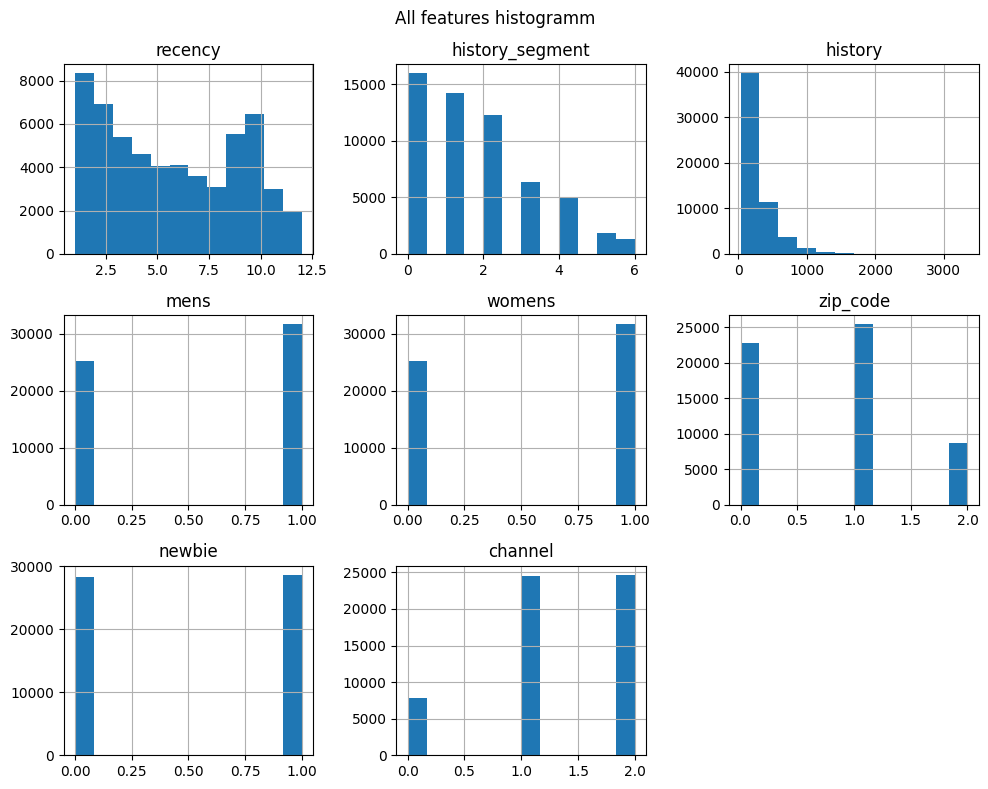

In [106]:
import matplotlib.pyplot as plt 
import seaborn as sns

features_all = ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']
treatment = ['treatment']
target = ['target']

ax = plt.subplot(1,1,1)
data[features_all].hist(bins=12, ax=ax)
ax.figure.set_size_inches((10,8))
ax.figure.suptitle('All features histogramm')
ax.figure.tight_layout()

# сохраним в файл
ax.figure.savefig('EDA/features_histogram.png', bbox_inches='tight')


Рассмотрим дополнительно признак `history` - так как значения очень малые на хвосте, применим логарифмический масштаб

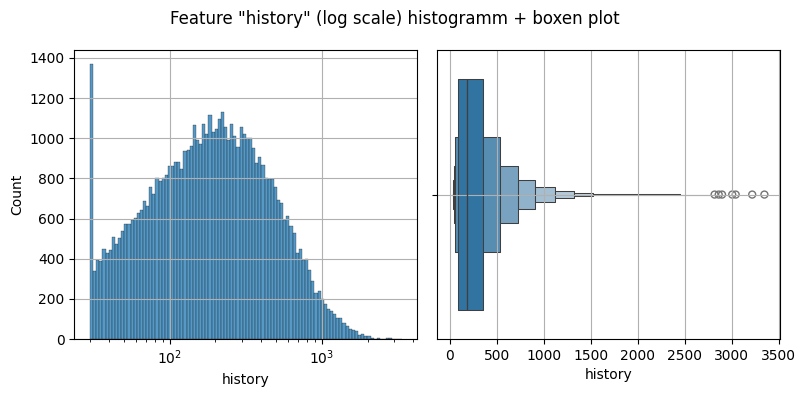

In [99]:
fig, axs = plt.subplots(1,2)
fig.set_size_inches(8,4)

ax1 = sns.histplot(data, x='history', log_scale=True, bins=100, ax=axs[0])
ax1.grid()
ax2 = sns.boxenplot(data, x='history', ax=axs[1])
ax2.grid()

fig.suptitle('Feature "history" (log scale) histogramm + boxen plot')
fig.tight_layout()

# сохраним в файл
fig.savefig('EDA/history_feature_outliers.png', bbox_inches='tight')


Что это за горб в районе значения "30"

In [122]:
data.query('history <= 30')['history'].describe()

count    981.000000
mean      29.990020
std        0.000451
min       29.990000
25%       29.990000
50%       29.990000
75%       29.990000
max       30.000000
Name: history, dtype: float64

#### Результат
- в основном признаки распределены более-менее равномерно
- выбивается только признак "history" 
    - со значениями более 2000 в райное 10 и менее записей
    - с дополнительным горбом в значении = 29.99 (что за волшебное число ..)

### Построение корреляций

- проанализируем взаимодействие признаков, целевой переменной (target) и воздействия (treatment) 
- выполним анализ с помощью корреляционной матрицы признаков и визуализируем ее с помощью "тепловой карты"
- построим графики зависимостей между признаками 

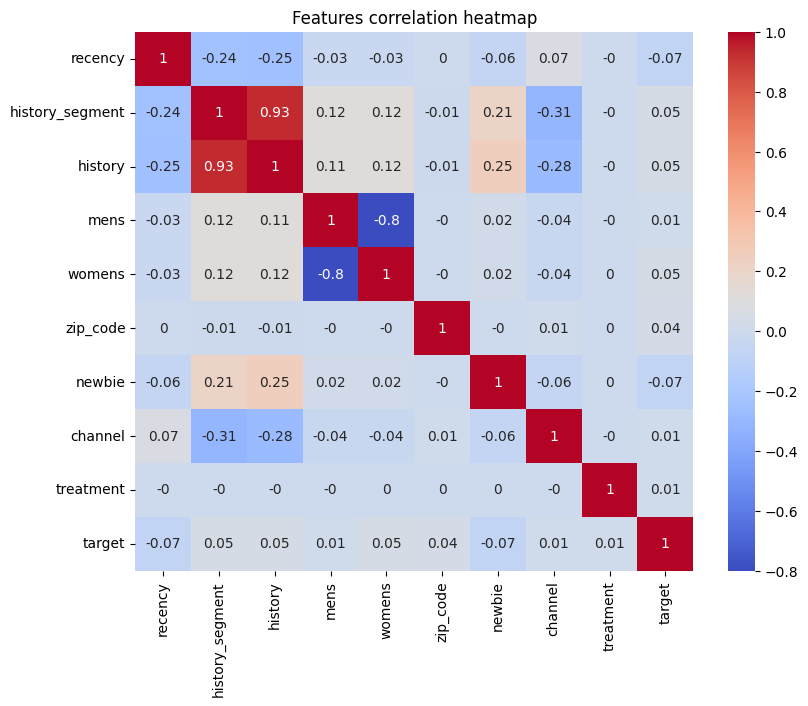

In [210]:
import matplotlib.pyplot as plt 
import seaborn as sns

correlation_data = data.corr()

plt.figure(figsize=(9, 7))
ax = sns.heatmap(correlation_data.round(2),  annot=True, cmap="coolwarm")
ax.set_title('Features correlation heatmap')

# сохраним в файл
ax.figure.savefig('EDA/corr-heatmap.png', bbox_inches='tight')

Результат
- корреляции между признаками и таргетом не выявлено
- корреляции между признаками и воздействием (treatment) не выявлено
- сильная корреляция между признаками:
    - history_segment и history - очевидно history_segent это категориальный признак, который дает большее значение для большего history
- сильная отрицательная корреляция между признаками:
    - mens и womens - логично, тут полная противоположность полов

Посмотрим зависимости признаков с высокой корреляцией 

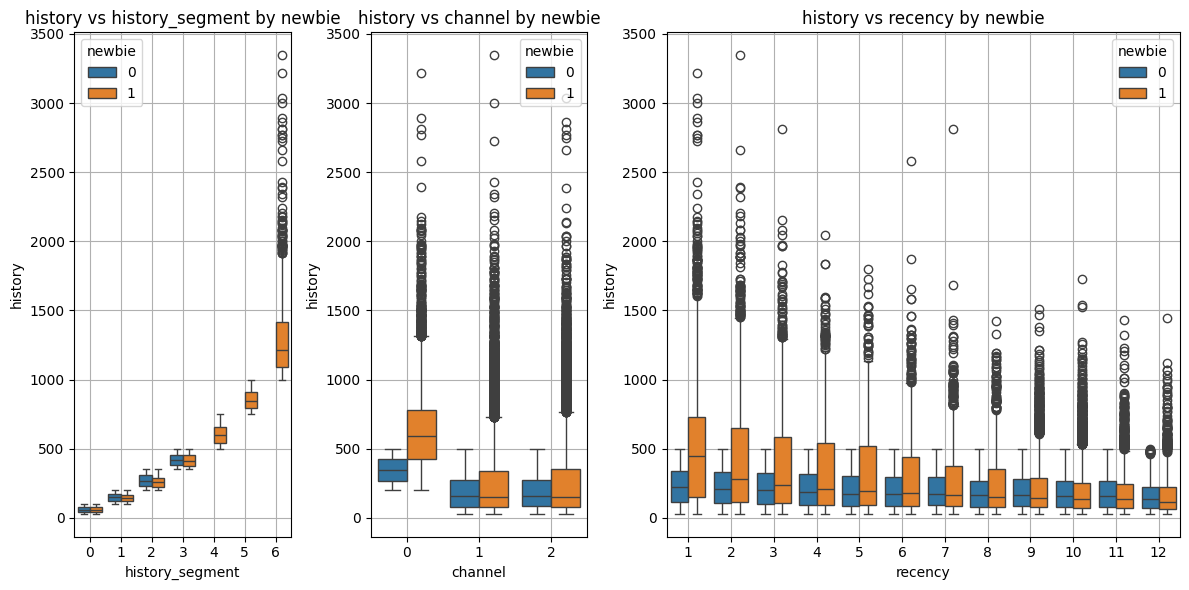

In [19]:
import matplotlib.pyplot as plt 
import seaborn as sns

fig = plt.figure(figsize=(12,6))

ax1 = plt.subplot2grid((1,4), (0,0))
ax1 = sns.boxplot(data_cleaned, x='history_segment', y='history', hue='newbie', ax=ax1)
ax1.set_title('history vs history_segment by newbie')
ax1.grid(True)

ax2 = plt.subplot2grid((1,4), (0,1))
ax2 = sns.boxplot(data_cleaned, x='channel', y='history', hue='newbie', ax=ax2)
ax2.set_title('history vs channel by newbie')
ax2.grid(True)

ax3 = plt.subplot2grid((1, 4), (0,2), colspan=2)
ax3 = sns.boxplot(data_cleaned, x='recency', y='history', hue='newbie', ax=ax3)
ax3.set_title('history vs recency by newbie')
ax3.grid(True)

plt.tight_layout()

# сохраним в файл
fig.savefig('EDA/history-vs-features.png', bbox_inches='tight')

Результат
- интересно, что б'ольшие суммы трат (покупок) совершили только "новички" (newbie) в категориях 4-6 (от 500р.)
- странно, что старые клиенты делали покупки в каждом месяце (recency) на очень малые суммы - 100-300р - похоже, что это шаурма .. или гамбургер, но никак не рестораны 
- новички тоже совершали покупки в каждом месяце, на чуть большие суммы в среднем и с гораздо большим количеством выбросов на суммы от 1000р и выше 
- чуть больше покупоку совершили в канале "0", в каналах "1", "2" - распределение сумм покупок одинаковое

Посмотрим зависимости признаков и таргета

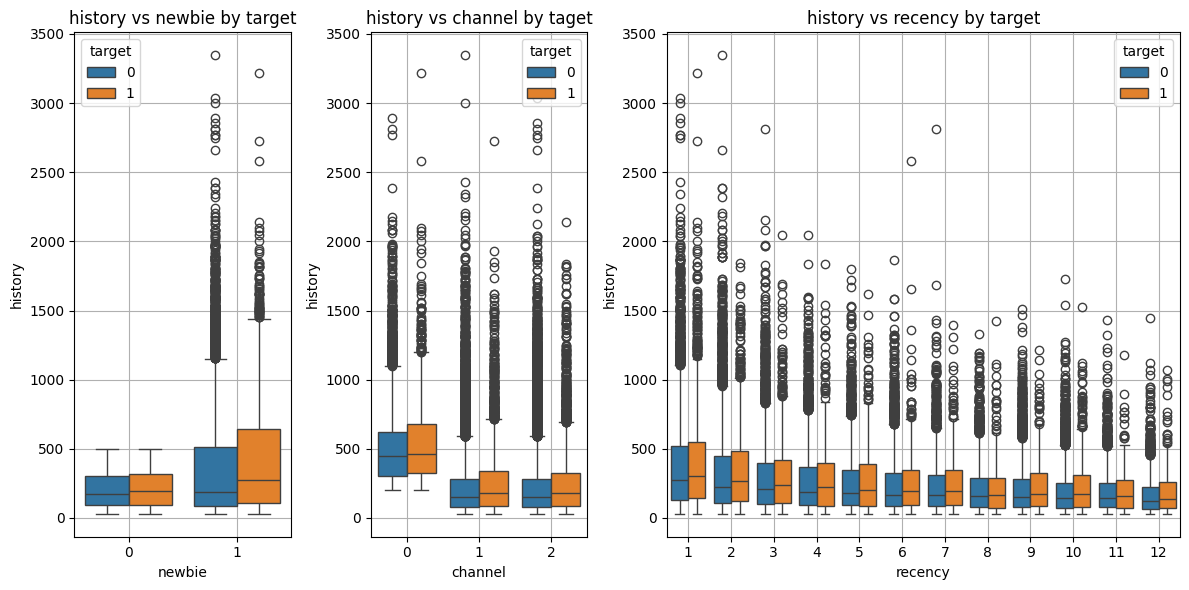

In [20]:
import matplotlib.pyplot as plt 
import seaborn as sns

fig = plt.figure(figsize=(12,6))

ax1 = plt.subplot2grid((1,4), (0,0))
ax1 = sns.boxplot(data_cleaned, x='newbie', y='history', hue='target', ax=ax1)
ax1.set_title('history vs newbie by target')
ax1.grid(True)

ax2 = plt.subplot2grid((1,4), (0,1))
ax2 = sns.boxplot(data_cleaned, x='channel', y='history', hue='target', ax=ax2)
ax2.set_title('history vs channel by taget')
ax2.grid(True)

ax3 = plt.subplot2grid((1, 4), (0,2), colspan=2)
ax3 = sns.boxplot(data_cleaned, x='recency', y='history', hue='target', ax=ax3)
ax3.set_title('history vs recency by target')
ax3.grid(True)

plt.tight_layout()

# сохраним в файл
fig.savefig('EDA/history-vs-target.png', bbox_inches='tight')

Результат
- целевая переменная довольно равномерно распределена по всем категориям - среди новичков, по каналам, по вовлеченности (recency)

Посмотрим зависимости признаков и воздействия

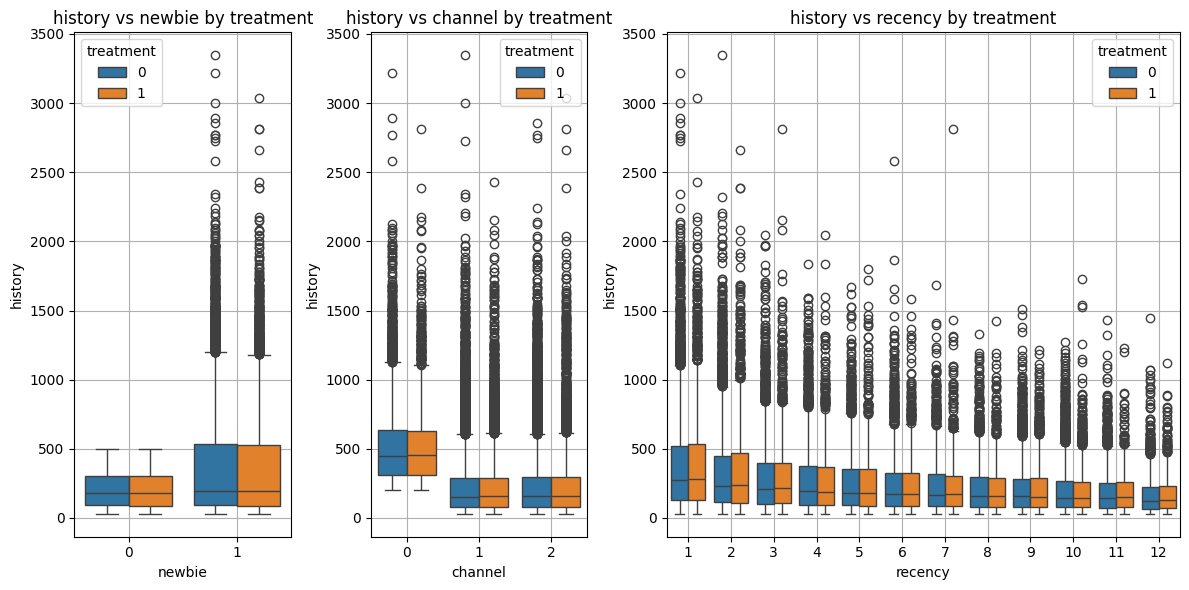

In [21]:
import matplotlib.pyplot as plt 
import seaborn as sns

fig = plt.figure(figsize=(12,6))

ax1 = plt.subplot2grid((1,4), (0,0))
ax1 = sns.boxplot(data_cleaned, x='newbie', y='history', hue='treatment', ax=ax1)
ax1.set_title('history vs newbie by treatment')
ax1.grid(True)

ax2 = plt.subplot2grid((1,4), (0,1))
ax2 = sns.boxplot(data_cleaned, x='channel', y='history', hue='treatment', ax=ax2)
ax2.set_title('history vs channel by treatment')
ax2.grid(True)

ax3 = plt.subplot2grid((1, 4), (0,2), colspan=2)
ax3 = sns.boxplot(data_cleaned, x='recency', y='history', hue='treatment', ax=ax3)
ax3.set_title('history vs recency by treatment')
ax3.grid(True)

plt.tight_layout()

# сохраним в файл
fig.savefig('EDA/history-vs-treatment.png', bbox_inches='tight')

Результат
- воздействие почти идеально поровну распределено по всем категориям - среди новичков, по каналам, по вовлеченности (recency)

Посмотрим на распределение на целевой переменной/конверсии и воздействия среди новичков и старых клиентов

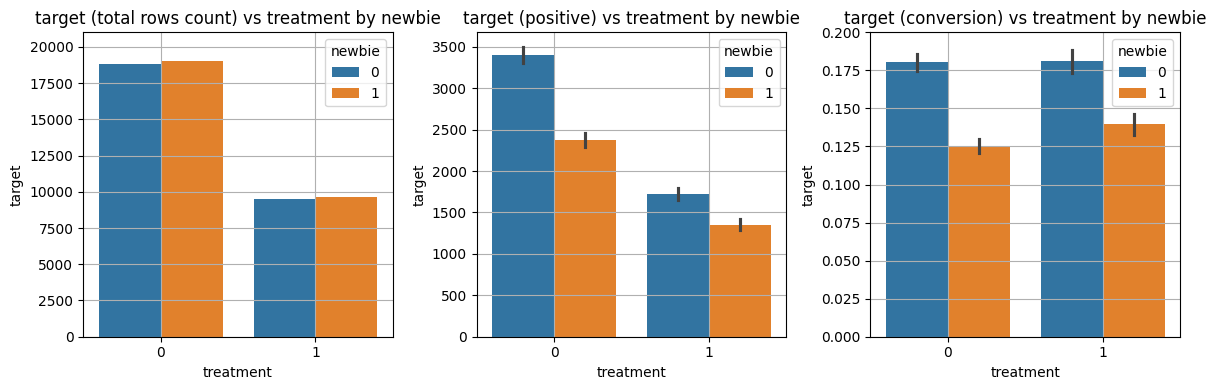

In [22]:
fig, axs = plt.subplots(1,3, figsize=(12,4))

ax1 = sns.barplot(data_cleaned, x='treatment', y='target', hue='newbie', estimator='size', ax=axs[0])
ax1.set_ylim(0, 21000)
ax1.set_title('target (total rows count) vs treatment by newbie')
ax1.grid(True)

ax2 = sns.barplot(data_cleaned, x='treatment', y='target', hue='newbie', estimator='sum', ax=axs[1])
ax2.set_title('target (positive) vs treatment by newbie')
ax2.grid(True)

ax3 = sns.barplot(data_cleaned, x='treatment', y='target', hue='newbie', estimator='mean', ax=axs[2])
ax3.set_ylim(0, 0.2)
ax3.set_title('target (conversion) vs treatment by newbie')
ax3.grid(True)

fig.tight_layout()

# сохраним в файл
fig.savefig('EDA/target-vs-treatment-by-newbie.png', bbox_inches='tight')


In [ ]:
group_newbie = data_cleaned.groupby(by=['treatment', 'newbie']).agg(
        group_count=('target', 'count'),
        target_action=('target', 'sum'),
        conversion=('target', lambda x: round(x.mean(), 6))).reset_index()
display(group_newbie)
# сохраним в файл
group_newbie.to_csv('EDA/group_newbie.csv')

non_treat_olds = group_newbie[(group_newbie['treatment'] == 0) & (group_newbie['newbie'] == 0)]['conversion'].values[0]
treat_olds = group_newbie[(group_newbie['treatment'] == 1) & (group_newbie['newbie'] == 0)]['conversion'].values[0]
uplift_olds = treat_olds - non_treat_olds 

non_treat_news = group_newbie[(group_newbie['treatment'] == 0) & (group_newbie['newbie'] == 1)]['conversion'].values[0]
treat_news = group_newbie[(group_newbie['treatment'] == 1) & (group_newbie['newbie'] == 1)]['conversion'].values[0]
uplift_news = treat_news - non_treat_news 

print(f'uplift for old cliens = {100*uplift_olds:.2f}%, relative uplift = {100*uplift_olds/non_treat_olds:.2f}%')
print(f'uplift for new cliens = {100*uplift_news:.2f}%, relative uplift = {100*uplift_news/non_treat_news:.2f}%')

,treatment,newbie,group_count,target_action,conversion
0,0,0,18834,3400,0.180525
1,0,1,18992,2375,0.125053
2,1,0,9508,1722,0.181111
3,1,1,9651,1347,0.139571


uplift for old cliens = 0.06%, relative uplift = 0.32%
uplift for new cliens = 1.45%, relative uplift = 11.61%


Результат
- как было ранее отмечено - воздействие получило примерно половино выборки
- воздействие одинаково распределено на новых и старых клиентов
- в обеих группах ("без воздействия" и "с воздействием") больше целевых действий выполнили "старые клиенты"
    - конверсия без воздействия
        - старые клиенты - 18,05%
        - новые клиенты - 12,50%
    - конверсия с воздействием
        - старые клиенты - 18,11%, uplift = 0.06%, прирост = 0.32% (незначимо)
        - новые клиенты - 13,96%, uplift = 1,45% (значимо), прирост = 11,61%
        -
- Важно - значимый uplift наблюдается только для новых клиентов, увеличение = 11,61%


#### Выводы

Сводные выводы по проведенным выше разделам о корреляциях признаков друг с другом и таргетом

- корреляции между признаками и таргетом не выявлено
    - целевая переменная довольно равномерно распределена по всем категориям - среди новичков, по каналам, по вовлеченности (recency)

- корреляции между признаками и воздействием (treatment) не выявлено
    - воздействие почти идеально поровну распределено по всем категориям - среди новичков, по каналам, по вовлеченности (recency)
    
- сильная корреляция между признаками:
    - history_segment и history - очевидно history_segent это категориальный признак, который дает большее значение для большего history    

- сильная отрицательная корреляция между признаками:
    - mens и womens - логично, тут полная противоположность полов

- интересные наблюдения
    - интересно, что б'ольшие суммы трат (покупок) совершили только "новички" (newbie) в категориях 4-6 (от 500р.)
    - странно, что старые клиенты делали покупки в каждом месяце (recency) на очень малые суммы - 100-300р - похоже, что это шаурма .. или гамбургер, но никак не рестораны 
    - новички тоже совершали покупки в каждом месяце, на чуть большие суммы в среднем и с гораздо большим количеством выбросов на суммы от 1000р и выше 
    - чуть больше покупоку совершили в канале "0", в каналах "1", "2" - распределение сумм покупок одинаковое

- распределение воздействия
    - как было ранее отмечено - воздействие получило примерно половино выборки
    - воздействие одинаково распределено на новых и старых клиентов
    - в обеих группах ("без воздействия" и "с воздействием") больше целевых действий выполнили "старые клиенты"
        - конверсия без воздействия
            - старые клиенты - 18,05%
            - новые клиенты - 12,50%
        - конверсия с воздействием
            - старые клиенты - 18,11%, uplift = 0.06%, прирост = 0.32% (незначимо)
            - новые клиенты - 13,96%, uplift = 1,45% (значимо), прирост = 11,61%

- Важно - значимый uplift наблюдается только для новых клиентов, увеличение = 11,61%
---
все комментарии по анализу сохранены в `EDA/eda_results.md` вместе с сопуствующими графиками



### Логирование результатов в MLflow
- сохраним результаты и артефакты Этапа 2 (EDA) в MLflow 
    - анализ выборки
    - анализ статистической значимости результатов конверсии
    - анализ взаимодействия признаков и целевой переменной

In [109]:
import pandas as pd

data = pd.read_csv('data/initial/uplift_fp_data.csv')
data_cleaned = pd.read_csv('data/uplift_fp_data_cleaned.csv')

In [110]:
import mlflow
from mlflow.data.sources import LocalArtifactDatasetSource
from dotenv import load_dotenv

# --- логирование в MLflow результатов EDA

TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000
MLFLOW_SERVER_URL = f'http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}'

load_dotenv()

mlflow.set_tracking_uri(MLFLOW_SERVER_URL)
mlflow.set_registry_uri(MLFLOW_SERVER_URL)

mlflow_client = mlflow.MlflowClient(mlflow.get_tracking_uri(), mlflow.get_registry_uri())

EXPERIMENT_NAME = "sprint-5-uplift-project-alex-khromenko" 
RUN_NAME = "step-2-eda-results"

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if not experiment:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
else:
    experiment_id = experiment.experiment_id

ds_orig = mlflow.data.from_pandas(df=data, source=LocalArtifactDatasetSource('data/initial/uplift_fp_data.csv'), name='initial_dataset')
ds_cleand = mlflow.data.from_pandas(df=data_cleaned, source=LocalArtifactDatasetSource('data/uplift_fp_data_cleaned.csv'), name='cleaned_dataset')

with mlflow.start_run(run_name=RUN_NAME, description='Этап 2 - Проведение исследовательского анализа данных' , experiment_id=experiment_id) as run:
    run_id = run.info.run_id
    print(f'run info: {run.info}')

    mlflow.log_input(ds_orig, context='EDA')
    mlflow.log_input(ds_cleand,context='EDA')
    
    mlflow.log_artifacts(artifact_path='Datasets', local_dir='./data/')
    mlflow.log_artifacts(artifact_path='EDA', local_dir='./EDA/')

### ---
run = mlflow_client.get_run(run_id=run_id)
print(f'run finish info: {run.info}')


/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/mlflow/data/digest_utils.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  string_columns = trimmed_df.columns[(df.applymap(type) == str).all(0)]
/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/mlflow/data/digest_utils.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  string_columns = trimmed_df.columns[(df.applymap(type) == str).all(0)]


run info: <RunInfo: artifact_uri='s3://s3-student-mle-20260306-f5465b0629-freetrack/Sprint-5/Project/16/d37d867a5461466a8b96981c792ea6e4/artifacts', end_time=None, experiment_id='16', lifecycle_stage='active', run_id='d37d867a5461466a8b96981c792ea6e4', run_name='step-2-eda-results', run_uuid='d37d867a5461466a8b96981c792ea6e4', start_time=1784196491650, status='RUNNING', user_id='mle-user'>


/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/mlflow/data/pandas_dataset.py:116: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  return _infer_schema(self._df)


run finish info: <RunInfo: artifact_uri='s3://s3-student-mle-20260306-f5465b0629-freetrack/Sprint-5/Project/16/d37d867a5461466a8b96981c792ea6e4/artifacts', end_time=1784196492214, experiment_id='16', lifecycle_stage='active', run_id='d37d867a5461466a8b96981c792ea6e4', run_name='step-2-eda-results', run_uuid='d37d867a5461466a8b96981c792ea6e4', start_time=1784196491650, status='FINISHED', user_id='mle-user'>


Данные сохранены в MLflow
- experiment_id='16', 
- run_name='step-2-eda-results'   
- <RunInfo: artifact_uri='s3://s3-student-mle-20260306-f5465b0629-freetrack/Sprint-5/Project/16/d37d867a5461466a8b96981c792ea6e4/artifacts', end_time=1784196492214, experiment_id='16', lifecycle_stage='active', run_id='d37d867a5461466a8b96981c792ea6e4', run_name='step-2-eda-results', run_uuid='d37d867a5461466a8b96981c792ea6e4', start_time=1784196491650, status='FINISHED', user_id='mle-user'>


## Этап 3

Выполнить шаги
- На основе EDA обосновать в отдельной md-ячейке выбор конкретной uplift-модели для обучения
- разбить данные на тренировочную и тестовую выборки с учетом стратификации по таргету и воздействию в соотношении 80% на 20% (не забыть про random_state=42)
- обучить baseline выбранной модели, получить метрики Uplift AUC, Qini AUC, Uplift@30%
- важность признаков представить в виде графика, чтобы визуально отобразить какие из них оказывают наибольшее влиения не предсказание модели
- обучить 2 любые модели из списка (S-, T-, X-, R-learner, uplift-деревья), 
    - в качестве базовых алгоритмов использовать такие же алгоритмы с одинаковыми гиперпараметрами, как и для baseline, 
    - получить метрики для каждой модели
- сравнить модели с выбранным baseline и понять почему существуют различия в метриках
- (Опцинально) залогировать артефакты модели в MLflow вместе 
    - с метриками, 
    - важностью признаков 
    - и другими артефактами (графики, таблицы и т.д.)
    - убедитесь, что все артефакты имеют четкие понятные названия, чтобы их можно было легко идентифицировать в будущем 
    - для метрик используйте стандартные показатели (точность, полнота, f1-score, AUC-ROC), чтобы оценить производительность модели

Обоснование выбора конкретной uplift модели

Описание данных:
- данные по количеству участников в группах несбалансированы
    - 2-х кратный перекос в сторону контрольной группы - тестовая группа составляет 50.65% от контольной (37826 / 19159).
- распределение целевой переменной в группах несбалансировано 
    - значение "1" примерно у 15% участников в каждой группе
- имеются выбросы и неравномерное распределение признака `history`
- наличие категорийных (mens, womens, newbie, channel, history_category, zip_code) и численных данных (history, recency)
- сильных корреляций не обнаружено 
- возможно наличие нелинейных связей
- объем данных минимально  достаточен для обучения любой модели 
    - целевая переменная в "тестовой группе" (если разбивать на контрольную и тестовую группу по отдельности) имеет 3069 записей, при разбиении выборки на обучающую и валидационную в пропорции 80х20% для обучения будет доступно 2455 записей (в контрольной группе записей еще больше) 
    - при этом, вероятно, существует риск переобучения у сложных моделей (запоминания всех обучающих данных)

Выбор моделей:

- для baseline-модели выберем T-learner, так как группы не сбалансированы и две независимые модели могут дать более точный расчет
    - в качестве внутренней модели-оценщика рассмотрим варианта 
        - LogisticRegression - самая простая линейная модель, высокая интерпретируемость результатов, чувствительна к предобработке данных и выбросам, не сможет выделить нелинейные зависимости 
        - CatboostClassifier - продвинутая модель, работает как с категорийными данными, там и с численными напрямую, имеет базовые настройки из коробки, не требует мастшабирования, устойчива к выбросам, есть риск переобучения
        - XGBClassifier = продвинутая модель, работает с численными данными, чувствительна к настройкам гиперпараметров, есть риск переобучения
        - RandomForrestClassier - строит ансамбли деревьев решений, может быть довольно эффективен и меньше риск переобучения
    
    - сделаем выбор в пользу RandomForrestClassier для базовой модели
[!! и дополнительно по-возможности - проверим на остальных .. RandomForrestClassier и проч.]

- в качестве 2-х других uplift-моделей возьмем X- и R-learner 
    - так как группы несбалансированы, то предпочтительно использовать подходы, учитывающие различную вероятность попадания участника в рызные группы (X или R)

### Советы по обучению и инференсу моделей
1. Некоторые uplift модели из библиотеки `causalml` будут требовать категориальные значения воздействия. Для этого используйте маппинг
#### Пример использования маппинга
```python
treatment_mapping = {
    0: 'control',
    1: 'treatment'
}
treatment_train_mapped = treatment_train.map(treatment_mapping)
treatment_test_mapped = treatment_test.map(treatment_mapping)
```

2. При вызове метода `.predict` и получения метрик для тестовой выборки не забывайте применять к прогнозам метод `squeeze()`, чтобы преобразовать многомерный массив в одномерный, что поможет получить адекватные метрики.

3. Для воспроизводимости результатов и объективной оценки не забывайте применять `random_state=42` для моделей, а также при разделении выборки

### Разбиение выборки на тренировочную и тестовую
- признак воздействия не передаем в baseline модель

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE=43

data = pd.read_csv('data/uplift_fp_data_cleaned.csv')

features = ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']
treatment = ['treatment']
target = ['target']

X = data[features]
y = data[target]
treat = data[treatment]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=data[target+treatment], random_state=RANDOM_STATE)
treat_train = treat.loc[X_train.index]
treat_test = treat.loc[X_test.index]

print(f'data: size = {X.shape[0]}, targets = {y.query("target == 1").size}, treatments = {treat.query("treatment == 1").size}')
print(f'train: size = {X_train.shape[0]}, targets = {y_train.query("target == 1").size}, treatments = {treat_train.query("treatment == 1").size}')
print(f'test: size = {X_test.shape[0]}, targets = {y_test.query("target == 1").size}, treatments = {treat_test.query("treatment == 1").size}')

## преобразуем к обычным массивам
y_train = y_train.values.squeeze()
y_test = y_test.values.squeeze()

treat_train = treat_train.values.squeeze()
treat_test = treat_test.values.squeeze()

data: size = 56985, targets = 8844, treatments = 19159
train: size = 45588, targets = 7075, treatments = 15327
test: size = 11397, targets = 1769, treatments = 3832


### Обучение выбранного бейзлайна

In [8]:
from sklearn.ensemble import RandomForestClassifier
from causalml.inference.meta import BaseTClassifier 
import numpy as np
import json

est_params = {
    'n_estimators': 100,
    'max_depth': 6,
    'random_state': RANDOM_STATE
}
# save to file to get in mlflow logging
with open('models/baseline/params.json', 'w', encoding='UTF-8') as f:
    json.dump(est_params, f, indent=4)

est_ctrl = RandomForestClassifier(
    n_estimators=est_params['n_estimators'],
    max_depth=est_params['max_depth'],
    random_state=est_params['random_state'])

est_trt = RandomForestClassifier(
    n_estimators=est_params['n_estimators'],
    max_depth=est_params['max_depth'],
    random_state=est_params['random_state'])

base_model = BaseTClassifier(control_learner=est_ctrl, treatment_learner=est_trt, control_name=0)

base_model.fit(X=X_train.values, treatment=treat_train, y=y_train)
pred_uplift = base_model.predict(X_test.values).squeeze()

# look at first 100 in descending order
np.sort(pred_uplift)[-1:-100:-1]


array([0.21364326, 0.20028394, 0.19402649, 0.19158173, 0.18652412,
       0.15472262, 0.14047925, 0.14043102, 0.14043102, 0.13520792,
       0.1326029 , 0.13116685, 0.12802035, 0.12472859, 0.12295307,
       0.12227393, 0.11591104, 0.11544757, 0.11357423, 0.11297054,
       0.11169343, 0.10870589, 0.10784302, 0.10612026, 0.10544544,
       0.10512649, 0.10015759, 0.09972509, 0.09790273, 0.09600636,
       0.09572153, 0.09275394, 0.0914549 , 0.09041959, 0.08868804,
       0.08768066, 0.08601406, 0.08601406, 0.08389631, 0.08274203,
       0.08204745, 0.08165105, 0.08147847, 0.08147186, 0.08147186,
       0.08089871, 0.08075439, 0.08059677, 0.08047772, 0.08037603,
       0.08004665, 0.08004665, 0.07949082, 0.07949082, 0.07949082,
       0.07872107, 0.07817262, 0.07816283, 0.07726366, 0.07676128,
       0.0766347 , 0.07654458, 0.07625689, 0.07623129, 0.07610983,
       0.07580914, 0.07549551, 0.07541224, 0.07514568, 0.07512983,
       0.07475037, 0.07471434, 0.07407989, 0.07392016, 0.07391

### Важность признаков baseline-модели
Рассмотрим важность признаков

,feature,importance
0,womens,0.717408
1,history,0.099406
2,mens,0.063209
3,zip_code,0.044036
4,newbie,0.042290
5,recency,0.019821
6,channel,0.011849
7,history_segment,0.001981


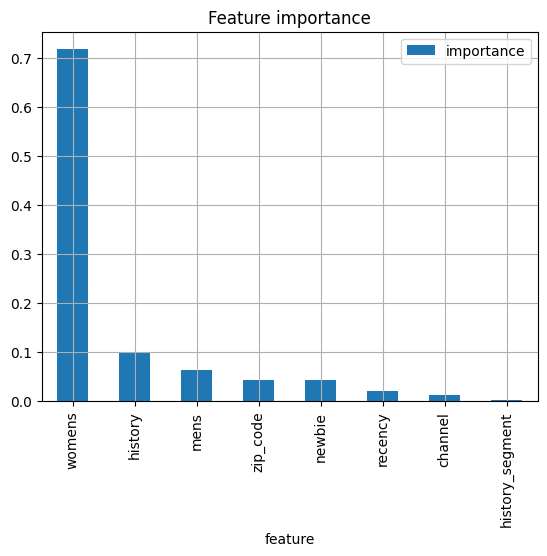

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

plt.style.use('default')

fi = base_model.get_importance(
    X=X_test, 
    tau=pred_uplift, 
    features=features, 
    model_tau_feature=RandomForestRegressor(
        n_estimators=est_params['n_estimators'],
        max_depth=est_params['max_depth'],
        random_state=RANDOM_STATE),
    random_state=RANDOM_STATE
)
fi_df = pd.DataFrame.from_dict(fi[1]).reset_index()
fi_df.columns = ['feature', 'importance']
display(fi_df)

fi_df.plot.bar(x='feature', title='Feature importance')
plt.grid()

# save to file
plt.savefig('models/baseline/fi-score.png', bbox_inches='tight')

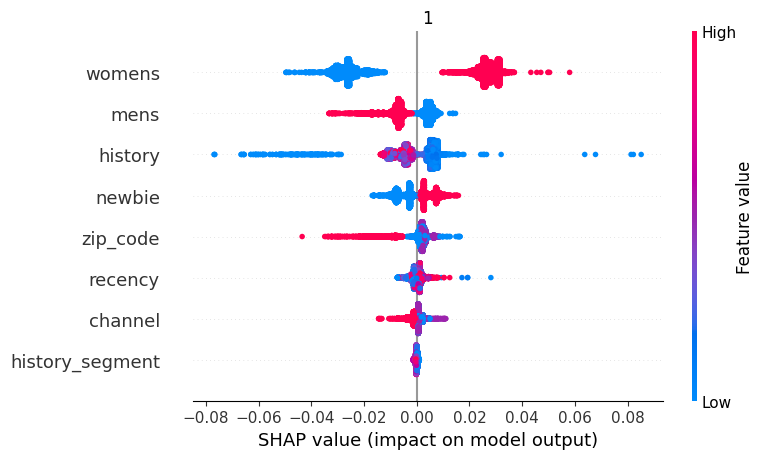

In [116]:
fig, axs = plt.subplots(1,1)
base_model.plot_shap_values(
    X=X_test, 
    tau=pred_uplift, 
    features=features,
    model_tau_feature=RandomForestRegressor(
        n_estimators=est_params['n_estimators'],
        max_depth=est_params['max_depth'],
        random_state=RANDOM_STATE)
)
fig.suptitle('Feature importance SHAP-values')
# save to file
fig.savefig('models/baseline/fi-shap.png', bbox_inches='tight')

#### Вывод
- наибольшее влияение оказал признак `womens` - видимо женщины (те кто покупал женские товары) более склонны к предложениям

### Расчет метрик для выбранного бейзлайна на тестовой выборке

1 - Метрики из библиотеки sklift

In [118]:
from sklift.metrics import uplift_auc_score, qini_auc_score, uplift_at_k
import json
import os

uplift_auc1 = uplift_auc_score(y_true=y_test, uplift=pred_uplift, treatment=treat_test)
qini_auc1 = qini_auc_score(y_true=y_test, uplift=pred_uplift, treatment=treat_test)
uplift_at_30 = uplift_at_k(y_true=y_test, uplift=pred_uplift, treatment=treat_test, k=0.3, strategy='overall')

print(f'sklift uplift_auc = {100*uplift_auc1:.2f}%, qini_auc = {100*qini_auc1:.2f}%, uplift_at_30 = {100*uplift_at_30:.2f}%')

metrics = {
    'uplift_auc': uplift_auc1.round(4),
    'qini_auc': qini_auc1.round(4),
    'uplift_at_30': uplift_at_30.round(4)
    }
with open('models/baseline/metrics.json', 'w', encoding='UTF-8') as f:
    json.dump(metrics, f, indent=4)

sklift uplift_auc = 1.59%, qini_auc = 3.24%, uplift_at_30 = 3.17%


Получены метрики
- uplift_auc = 1.59%
- qini_auc = 3.24%
- uplift_at_30 = 3.17%

2 - Метрики из библиотеки causalml - справочно

In [21]:
from causalml.metrics import auuc_score, qini_score
df = pd.DataFrame({
    'y': y_test,
    'w': treat_test,
    'uplift': pred_uplift
})
uplift_auc2 = auuc_score(df, outcome_col='y', treatment_col='w', normalize=True)['uplift']
qini_auc2 = qini_score(df, outcome_col='y', treatment_col='w', normalize=True)['uplift']

print(f'causalml uplift_auc = {100*uplift_auc2:.2f}%, qini_auc = {100*qini_auc2:.2f}%')

causalml uplift_auc = 113.26%, qini_auc = 61.88%


Метрики `causalml` дают немасштабированные результаты, поэтому их пока применять не будем
- causal uplift_auc = 113.26%, qini_auc = 61.88%

#### Построим графики uplift-curve и qini-curve

In [ ]:
# не работает - возникает ошибка - ImportError: cannot import name 'check_matplotlib_support' from 'sklearn.utils' 

#from sklift.viz import plot_qini_curve
#plot_qini_curve(y_test, pred_uplift, treat_test)

In [ ]:
%reload_ext autoreload

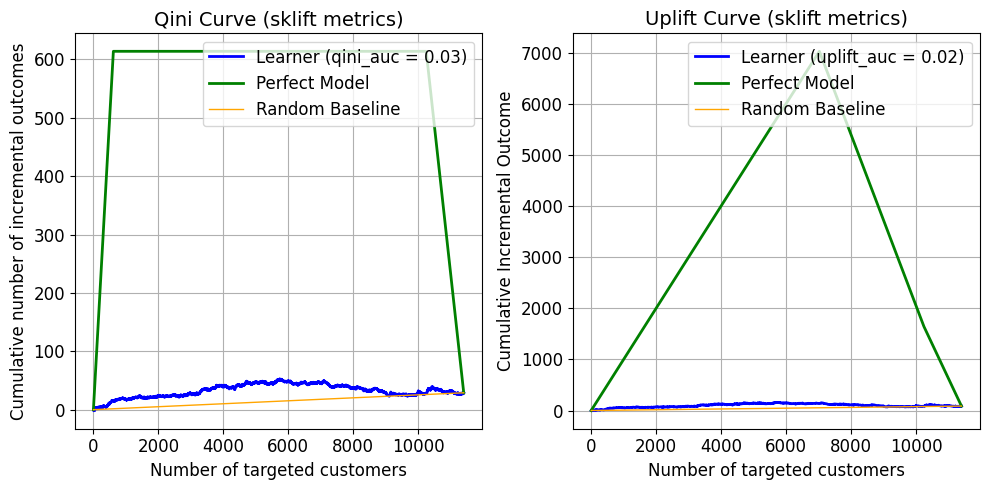

In [112]:
# построим графики вручную на основе данных из sklift
import matplotlib.pyplot as plt 
import utils

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

utils.plot_qini_curve(y_test, pred_uplift, treat_test, axs=axs[0])
utils.plot_uplift_curve(y_test, pred_uplift, treat_test, axs=axs[1])

plt.tight_layout()

fig.savefig('models/baseline/qini_uplif_curves.png')

Графики из библиотеки causalml тоже выведем (но не совсем понятно как их интерпретировать)

Text(0.5, 0.98, 'CausalML uplift curve')

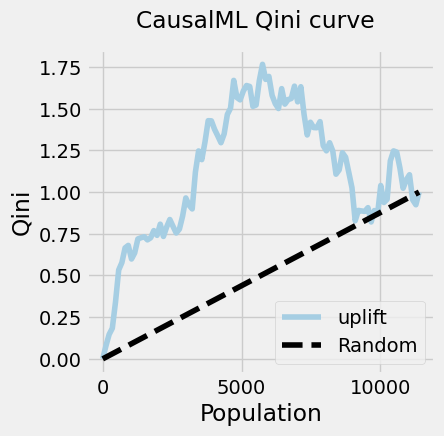

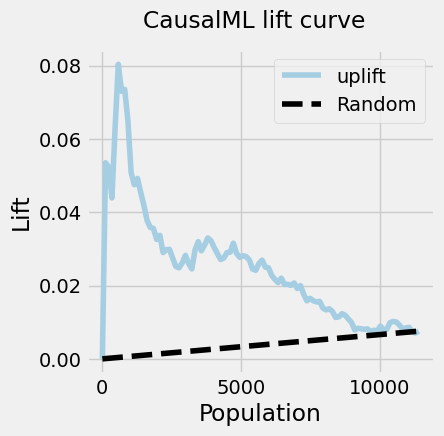

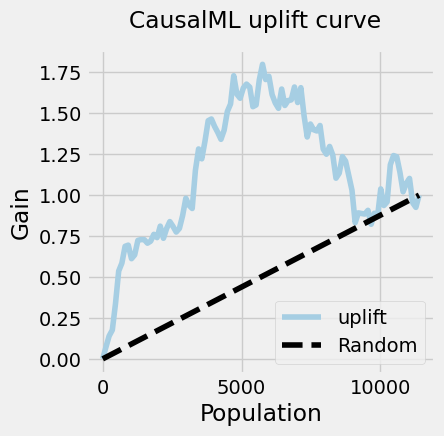

In [7]:
import matplotlib.pyplot as plt
from causalml.metrics import plot_qini, plot_lift, plot_gain

plot_qini(df, outcome_col='y', treatment_col='w', normalize=True, figsize=(4,4))
plt.suptitle('CausalML Qini curve')

plot_lift(df, outcome_col='y', treatment_col='w', figsize=(4,4))
plt.suptitle('CausalML lift curve')

plot_gain(df, outcome_col='y', treatment_col='w', normalize=True, figsize=(4,4))
plt.suptitle('CausalML uplift curve')

#### Вывод
- получены значения метрик, показывает, что baseline-модель все-таки смогла выделить клиентов склонных к предложениям, хоть и с невысокими значениями метрик
    - uplift_auc = 1.59%
    - qini_auc = 3.24%
    - uplift_at_30 = 3.17% 

### Логирование baseline-модели в MLflow
- сохраним результаты и артефакты обучения baseline-модели в MLflow 
    - анализ выборки
    - анализ статистической значимости результатов конверсии
    - анализ взаимодействия признаков и целевой переменной

Обертак для sklift модели, чтобы залогировать как pyfunc

In [1]:
import mlflow
import mlflow.pyfunc

class SkliftTClassifierWrapper(mlflow.pyfunc.PythonModel):
    def load_context(self, context):
        self.model = mlflow.sklearn.load_model(context.artifacts["sklift_model"])

    def predict(self, context, model_input):
        return self.model.predict(model_input)

In [9]:
import mlflow, mlflow.sklearn, mlflow.pyfunc
import json
import os
import shutil
from dotenv import load_dotenv


# --- логирование в MLflow результатов EDA

TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000
MLFLOW_SERVER_URL = f'http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}'

load_dotenv()

mlflow.set_tracking_uri(MLFLOW_SERVER_URL)
mlflow.set_registry_uri(MLFLOW_SERVER_URL)

mlflow_client = mlflow.MlflowClient(mlflow.get_tracking_uri(), mlflow.get_registry_uri())

EXPERIMENT_NAME = "sprint-5-uplift-project-alex-khromenko" 
RUN_NAME = "step-3-baseline-model"

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if not experiment:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
else:
    experiment_id = experiment.experiment_id

ds_train = mlflow.data.from_pandas(df=X_train, name='train_dataset')
ds_val = mlflow.data.from_pandas(df=X_test, name='validation_dataset')

local_path = 'models/baseline'
with open(f'{local_path}/metrics.json', 'r', encoding='UTF-8') as f:
    metrics = json.load(f)

with open(f'{local_path}/params.json', 'r', encoding='UTF-8') as f:
    est_params = json.load(f)

local_model_path = f'{local_path}/tlearner'
if os.path.exists(local_model_path):
    shutil.rmtree(local_model_path)

with mlflow.start_run(run_name=RUN_NAME, description='Этап 3 - Построение baseline-модели' , experiment_id=experiment_id) as run:
    run_id = run.info.run_id
    print(f'run info: {run.info}')

    mlflow.log_input(ds_train, context='train')
    mlflow.log_input(ds_val, context='validate')
    
    mlflow.log_artifacts(artifact_path='model-perfomance', local_dir=local_path)
    mlflow.log_metrics(metrics=metrics)
    mlflow.log_params(est_params)
    
    mlflow.sklearn.save_model(sk_model=base_model, path=local_model_path)
    artifacts = {"sklift_model": local_model_path}

    mlflow.pyfunc.log_model(
        python_model=SkliftTClassifierWrapper(),
        artifact_path='sklift-tlearner',
        artifacts=artifacts,
        input_example=X_train.head(),
        signature=mlflow.models.infer_signature(X_train, pred_uplift),
        pip_requirements='requirements.txt',
        metadata={
            'model-type': 'causalml.inference.meta.BaseTClassifier',
            'estimator': 'sklearn.ensemble.RandomForestClassifier'}
    )

### ---
run = mlflow_client.get_run(run_id=run_id)
print(f'run finish info: {run.info}')


/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/mlflow/data/digest_utils.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  string_columns = trimmed_df.columns[(df.applymap(type) == str).all(0)]
/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/mlflow/data/digest_utils.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  string_columns = trimmed_df.columns[(df.applymap(type) == str).all(0)]
/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/mlflow/data/pandas_dataset.py:116: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be 

run info: <RunInfo: artifact_uri='s3://s3-student-mle-20260306-f5465b0629-freetrack/Sprint-5/Project/16/72aa9badc3f646af8d3a1e6f958f4fa7/artifacts', end_time=None, experiment_id='16', lifecycle_stage='active', run_id='72aa9badc3f646af8d3a1e6f958f4fa7', run_name='step-3-baseline-model', run_uuid='72aa9badc3f646af8d3a1e6f958f4fa7', start_time=1784202403294, status='RUNNING', user_id='mle-user'>


/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/_distutils_hack/__init__.py:18: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/mlflow/models/signat

run finish info: <RunInfo: artifact_uri='s3://s3-student-mle-20260306-f5465b0629-freetrack/Sprint-5/Project/16/72aa9badc3f646af8d3a1e6f958f4fa7/artifacts', end_time=1784202407349, experiment_id='16', lifecycle_stage='active', run_id='72aa9badc3f646af8d3a1e6f958f4fa7', run_name='step-3-baseline-model', run_uuid='72aa9badc3f646af8d3a1e6f958f4fa7', start_time=1784202403294, status='FINISHED', user_id='mle-user'>


<RunInfo: artifact_uri='s3://s3-student-mle-20260306-f5465b0629-freetrack/Sprint-5/Project/16/72aa9badc3f646af8d3a1e6f958f4fa7/artifacts', end_time=1784202407349, experiment_id='16', lifecycle_stage='active', run_id='72aa9badc3f646af8d3a1e6f958f4fa7', run_name='step-3-baseline-model', run_uuid='72aa9badc3f646af8d3a1e6f958f4fa7', start_time=1784202403294, status='FINISHED', user_id='mle-user'>

Проверим, что модель можно загрузить и использовать

In [12]:
import mlflow
import pandas as pd

run_id = "72aa9badc3f646af8d3a1e6f958f4fa7"
model_uri = f"s3://s3-student-mle-20260306-f5465b0629-freetrack/Sprint-5/Project/16/{run_id}/artifacts/sklift-tlearner"

loaded_model = mlflow.pyfunc.load_model(model_uri)

test_predictions = loaded_model.predict(X_test.head(5))
test_predictions


2026/07/16 11:55:24 WARNING mlflow.pyfunc: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - cloudpickle (current: 2.2.1, required: cloudpickle==3.0.0)
 - numpy (current: 1.26.4, required: numpy==2.2.6)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.
/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


array([[ 0.05861574],
       [-0.02368623],
       [-0.01451038],
       [-0.03183975],
       [-0.00547876]])

### Обучение 2 моделей 

#### Обучение модели 1

#### Получение метрик по модели 1

#### Обучение модели 2

#### Получение метрик по модели 2

Проинтерпретируйте полученные результаты и обоснуйте выбор 1 модели в этой ячейке

# Часть 2

## Этап 1
Улучшите бейзлайн выбранной модели

#### Генерация признаков (опционально)

### Подбор гиперпараметров

In [ ]:
from optuna import create_study
from sklift.metrics import uplift_at_k

def objective(trial):
    # Дополните код для подбора гиперпараметров

    uplift_at_30 = uplift_at_k(y_test, uplift_pred, treatment_test, k=0.3, strategy='overall')
    return uplift_at_30

# Создаем и запускаем исследование
study = create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# Выводим лучшие гиперпараметры
print("Best hyperparameters: ", study.best_params)
print("Best score: ", study.best_value)


## Этап 2

### Визуализация результатов

In [ ]:
from utils import custom_uplift_by_percentile

В данной ячейке сделайте вывод о качестве работы модели и проинтерпретируйте график `uplift by percentile` 

# Этап 3

In [138]:
# Класс для инференса модели
class UpliftModelInference:
    """
    Класс для инференса uplift модели.
    """
    
    def __init__(self, model, feature_names, logger=None):
        """
        Инициализация класса.
        
        Аргументы:
            model: Обученная модель uplift
            feature_names: Список признаков для предсказания 
            logger: Объект для логирования (по умолчанию None)
        """
        self.model = model
        self.feature_names = ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']
        self.logger = logger
        
        if self.logger:
            self.logger.info("Модель UpliftModel инициализирована с признаками: %s", feature_names)

    def _transform_data(self, X):
        """
        Преобразование данных для модели.
        
        Аргументы:
            X: pandas.DataFrame с признаками
        """
        if self.logger:
            self.logger.debug("Преобразование входных данных размерности %s", X.shape)

        # реализуйте преобразование данных для модели,
        # если в финальной модели используются новые признаки
       

        return X
    
    def predict(self, X):
        """
        Получение предсказаний uplift.
        
        Аргументы:
            X: pandas.DataFrame с признаками
            
        Возвращает:
            numpy.array с предсказанными значениями uplift
        """
        # Проверяем, что датафрейм не пустой
        if X.empty:
            if self.logger:
                self.logger.error("Предоставлен пустой датафрейм")
            return None
            
        # Проверяем наличие пропущенных значений
        if X.isnull().any().any():
            if self.logger:
                self.logger.error("Входные данные содержат пропущенные значения")
            return [None]*len(X)
        
        if self.logger:
            self.logger.info("Выполняем предсказания для данных размерности %s", X.shape)

        # Проверяем наличие всех необходимых признаков
        missing_features = set(self.feature_names) - set(X.columns)
        if missing_features:
            error_msg = f"Отсутствуют признаки: {missing_features}"
            if self.logger:
                self.logger.error(error_msg)

            return [None]*len(X)
        
        # Преобразуем данные для модели
        if self.logger:
            self.logger.debug("Начинаем преобразование данных")
        X = self._transform_data(X)
        
        # Вычисляем uplift
        if self.logger:
            self.logger.debug("Выполняем предсказания модели")
        

        # Дополните код для получения предсказаний аплифта

        
        if self.logger:
            self.logger.info("Предсказания успешно завершены")
            
        return uplift


In [126]:
model = UpliftModelInference(model= # ваш код,
                             feature_names= # ваш код)

In [ ]:
test_data = pd.DataFrame({
            'recency': [1, 2, 3],
            'history_segment': [1, 2, 3], 
            'history': [100, 200, 300],
            'mens': [1, 0, 1],
            'womens': [0, 1, 0],
            'zip_code': [1, 0, 1],
            'newbie': [0, 1, 0],
            'channel': [1, 2, 0]
        })

In [ ]:
# проверка работы класса
model.predict(test_data)